In [1]:
import burecordbook as burb
import pandas as pd
import os
import numpy as np

In [2]:
burb.RECBOOK_DATA_PATH=r'C:\Users\nmemm\Documents\GitHub\buhockeystats\buhockeystatssite\recordbookdata'
burb.RECBOOK_DATA_PATH+="\\"
burb.initializeRecordBook()

In [3]:
dfCaptains=burb.getCaptains('M')
dfAwards=burb.getAwards('M')
dfPlayerData=burb.getPlayerData('M')
dfDraft=burb.getDraftData('nhl')
dfNhl=burb.getNHLers()
dfAllPlayersSeason=pd.concat([burb.dfSeasGoalieMens[['name','season','year']],burb.dfSeasSkateMens[['name','season','year']]]).drop_duplicates()
dfOlympians=burb.getOlympians('M')
dfOlympians['Name']=dfOlympians['Name'].str.replace(' (C)','').str.replace(' (A)','')
dfTrophies=burb.getTrophies('M')
dfTransfer=burb.getTransfers('M','In')
dfTransferOut=burb.getTransfers('M','Out')
dfWJC=burb.getWJC()
dfTrophies = dfTrophies.assign(
    year=dfTrophies['years won'].str.split(',')
).explode('year')

dfTrophies['year'] = dfTrophies['year'].str.strip().astype(int)

dfTrophies = dfTrophies[['trophy', 'year']]
burb.dfSeasSkateMens[['pen','PIM']]=burb.dfSeasSkateMens['pens'].str.split('/',expand=True)
burb.dfSeasSkateMens['PIM'] = burb.dfSeasSkateMens['PIM'].replace('—', np.nan).astype(float)

dfSkateExploded = burb.dfSkateMens.assign(
    season=burb.dfSkateMens['seasons'].str.split(',')
).explode('season')
dfGoalieExploded = burb.dfGoalieMens.assign(
    season=burb.dfGoalieMens['seasons'].str.split(',')
).explode('season')
dfJersey = burb.dfJerseyMens.assign(
    season=burb.dfJerseyMens['season'].str.split(',')
).explode('season')
dfJersey[['year','y2']]=dfJersey['season'].str.split('-',expand=True).astype(int)
dfJersey[['year']]=dfJersey[['year']]+1
dfJersey.drop('y2',axis=1,inplace=True)

dfAllPlayersSeason=pd.concat([dfSkateExploded[['name','season']],dfGoalieExploded[['name','season']]]).drop_duplicates().sort_values(['name','season'])
dfAllPlayersSeason[['year','y2']]=dfAllPlayersSeason['season'].str.split('-',expand=True).astype(int)
dfAllPlayersSeason[['year']]=dfAllPlayersSeason[['year']]+1
dfAllPlayersSeason.drop('y2',axis=1,inplace=True)

In [4]:
dfCaptainsW=burb.getCaptains('W')
dfAwardsW=burb.getAwards('W')
dfPlayerDataW=burb.getPlayerData('W')
dfDraftW=burb.getDraftData('pwhl')
dfPwhl=burb.getPWHLers()
dfAllPlayersSeasonW=pd.concat([burb.dfSeasGoalieWomens[['name','season','year']],burb.dfSeasSkateWomens[['name','season','year']]]).drop_duplicates()
dfOlympiansW=burb.getOlympians('W')
dfOlympiansW['Name']=dfOlympiansW['Name'].str.replace(' (C)','').str.replace(' (A)','')
dfTrophiesW=burb.getTrophies('W')
dfTransferW=burb.getTransfers('W','In')
dfTransferOutW=burb.getTransfers('W','Out')
dfWJCW=burb.getWJC()
dfTrophiesW = dfTrophiesW.assign(
    year=dfTrophiesW['years won'].str.split(',')
).explode('year')

dfTrophiesW['year'] = dfTrophiesW['year'].str.strip().astype(int)

dfTrophiesW = dfTrophiesW[['trophy', 'year']]
burb.dfSeasSkateWomens[['pen','PIM']]=burb.dfSeasSkateWomens['pens'].str.split('/',expand=True).astype(int)

dfJerseyW = burb.dfJerseyWomens.assign(
    season=burb.dfJerseyWomens['season'].str.split(',')
).explode('season')
dfJerseyW[['year','y2']]=dfJerseyW['season'].str.split('-',expand=True).astype(int)
dfJerseyW[['year']]=dfJerseyW[['year']]+1
dfJerseyW.drop('y2',axis=1,inplace=True)


In [64]:
## Options
jacksBoxesOptions={
# Career Stats dfSkateMens, dfGoalie Stats
'30+ Goals (Career)': burb.dfSkateMens.query('goals>=30').name,
'40+ Goals (Career)': burb.dfSkateMens.query('goals>=40').name,
'50+ Goals (Career)': burb.dfSkateMens.query('goals>=50').name,
'50+ Assists (Career)' : burb.dfSkateMens.query('assists>=50').name,
'100+ Points (Career)': burb.dfSkateMens.query('pts>=100').name,
'150+ Points (Career)': burb.dfSkateMens.query('pts>=150').name,

# Season Stats dfSeasSkate, dfSeasGoalie
'25+ Pts (Season)': burb.dfSeasSkateMens.query('pts>=25').name,
'33+ Pts (Season)': burb.dfSeasSkateMens.query('pts>=33').name,
'50+ Pts (Season)': burb.dfSeasSkateMens.query('pts>=50').name,
'60+ Pts (Season)': burb.dfSeasSkateMens.query('pts>=60').name,
'20+ Goals (Season)': burb.dfSeasSkateMens.query('goals>=20').name,
'30+ Goals (Season)': burb.dfSeasSkateMens.query('goals>=30').name,
'20+ Assists (Season)': burb.dfSeasSkateMens.query('assists>=20').name,
'30+ Assists (Season)': burb.dfSeasSkateMens.query('assists>=30').name,
'50+ PIM (Season)':burb.dfSeasSkateMens.query('PIM>=50').name,

# Position
'Forward': burb.dfSeasSkateMens.query('pos.str.contains("F")').name,
'Defenseman': burb.dfSeasSkateMens.query('pos.str.contains("D")').name,
'Goalie': burb.dfGoalieMens.name,
    
# Trophies
'Frozen Four' : dfAllPlayersSeason.loc[dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy=="Frozen Four"').year)].name,
'National Champion' : dfAllPlayersSeason.loc[dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy=="National Championship"').year)].name,
'Hockey East Tournament Champion':dfAllPlayersSeason.loc[dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy=="Hockey East Tournament"').year)].name,
'Hockey East Regular Season Champion' : dfAllPlayersSeason.loc[dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy=="Hockey East Regular Season"').year)].name,
'Regular Season Champion': dfAllPlayersSeason.loc[(dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy in ["NEIHL Regular Season","ECAC Regular Season","Hockey East Regular Season"]').year))].name,
'Beanpot Champion' : dfAllPlayersSeason.loc[dfAllPlayersSeason['year'].isin(dfTrophies.query('trophy=="Beanpot"').year)].name,

# Awards
'All-American': dfAwards.loc[(dfAwards['Award'].str.contains('All-American'))].Winner,
'All-Hockey East': dfAwards.loc[(dfAwards['Award'].str.contains('All-Hockey East')) & (~dfAwards['Award'].str.contains('Rookie'))].Winner,
'All-Hockey East Rookie Team':dfAwards.loc[(dfAwards['Award'].str.contains('All-Hockey East Rookie'))].Winner,
'BU Athletics Hall of Famer' : dfAwards.loc[(dfAwards['Award'].str.contains('BU Athletics Hall of Fame'))].Winner,
'Hall of Famer (HHOF, USHHOF, Beanpot, BU Athletics)' : dfAwards.loc[(dfAwards['Award'].str.contains('Hall of Fame'))].Winner,
'Beanpot MVP' : dfAwards.query('Award=="Most Valuable Player"').Winner,
'Eberly Award' : dfAwards.query('Award=="Eberly Award"').Winner,

# Game Stats
'Recorded a Point' :burb.dfGameStatsMens.query('pts>0').name,
'Scored a Goal' :burb.dfGameStatsMens.query('goals>0').name,
'Goal vs. BC' : burb.dfGameStatsMens.query('opponent=="Boston College" and goals>0').name,
'Goal vs. NU': burb.dfGameStatsMens.query('opponent=="Northeastern" and goals>0').name,
'Goal vs. Harvard' : burb.dfGameStatsMens.query('opponent=="Harvard" and goals>0').name,
'Goal vs. UNH' : burb.dfGameStatsMens.query('opponent=="New Hampshire" and goals>0').name,
'Goal vs. Providence' : burb.dfGameStatsMens.query('opponent=="Providence" and goals>0').name,
'Goal vs. Maine' : burb.dfGameStatsMens.query('opponent=="Maine" and goals>0').name,
'Goal vs. Merrimack' : burb.dfGameStatsMens.query('opponent=="Merrimack" and goals>0').name,
'Goal vs. Wisconsin' : burb.dfGameStatsMens.query('opponent=="Wisconsin" and goals>0').name,
'Goal vs. Holy Cross' : burb.dfGameStatsMens.query('opponent=="Holy Cross" and goals>0').name,
'Goal vs. Brown' : burb.dfGameStatsMens.query('opponent=="Brown" and goals>0').name,
'Goal vs. Colgate' : burb.dfGameStatsMens.query('opponent=="Colgate" and goals>0').name,
'Recorded a Point at Gutterson Fieldhouse' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Gutterson Fieldhouse" and pts>0').name,
'Goal at Gutterson Fieldhouse' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Gutterson Fieldhouse" and goals>0').name,
'Goal at Boston (Matthews) Arena': pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Boston Arena" or arena=="Matthews Arena" and goals>0').name,
'Goal at Whittemore Center' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Whittemore Center Arena" and goals>0').name,
'Goal at Boston Garden' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Boston Garden" and goals>0').name,
'Goal at TD Garden' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="TD Garden" and goals>0').name,
'Goal at Walter Brown Arena' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Walter Brown Arena" and goals>0').name,
'Goal at Agganis Arena' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Agganis Arena" and goals>0').name,
'Goal at Conte Forum' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Conte Forum" and goals>0').name,
'Goal in Beanpot' : pd.merge(burb.dfGames[['date','tourney']],burb.dfGameStatsMens).query('tourney=="Beanpot Tournament" and goals>0').name,
'Goal in NCAA Tournament' : pd.merge(burb.dfGames[['date','tourney']],burb.dfGameStatsMens).query('tourney=="NCAA Tournament" and goals>0').name,
'Goal in Hockey East Tournament' : pd.merge(burb.dfGames[['date','tourney']],burb.dfGameStatsMens).query('tourney=="Hockey East Tournament" and goals>0').name,
'Played at Frozen Fenway' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Fenway Park"').name,
'Goal in Oct.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==10].query('goals>0').name,
'Goal in Nov.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==11].query('goals>0').name,
'Goal in Dec.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==12].query('goals>0').name,
'Goal in Jan.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==1].query('goals>0').name,
'Goal in Feb.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==2].query('goals>0').name,
'Goal in Mar.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==3].query('goals>0').name,
'Goal in Apr.' : burb.dfGameStatsMens.loc[burb.dfGameStatsMens['date'].dt.month==4].query('goals>0').name,
'Recorded a Multi Goal Game': burb.dfGameStatsMens.query('goals>=2').name,
'Recorded a 3+ Point Game' : burb.dfGameStatsMens.query('pts>=3').name,
'Recorded a Multipoint Game vs. Brown' : burb.dfGameStatsMens.query('opponent=="Brown" and pts>1').name,

# Coach
'Played Under Jay Pandolfo': dfAllPlayersSeason.query('year>2022').name,
'Played Under David Quinn': dfAllPlayersSeason.query('year>2013 and year<=2018').name,
"Played Under Albie O'Connell": dfAllPlayersSeason.query('year>2018 and year<=2022').name,
"Played Under Jack Parker": dfAllPlayersSeason.query('year>1973 and year<=2013').name,

# Years
'Played in the 50s' : dfAllPlayersSeason.query('year>1949 and year<=1960').name,
'Played in the 60s' : dfAllPlayersSeason.query('year>1959 and year<=1970').name,
'Played in the 70s' : dfAllPlayersSeason.query('year>1969 and year<=1980').name,
'Played in the 80s' : dfAllPlayersSeason.query('year>1979 and year<=1990').name,
'Played in the 90s' : dfAllPlayersSeason.query('year>1989 and year<=2000').name,
'Played in the 00s' : dfAllPlayersSeason.query('year>1999 and year<=2010').name,
'Played in the 2010s' : dfAllPlayersSeason.query('year>2009 and year<=2020').name,
'Played in the 2020s' : dfAllPlayersSeason.query('year>2019 and year<=2030').name,
    
# Hatties / Shutouts
'Recorded a Hat Trick':burb.dfGameStatsMens.query('goals>=3').name,
'Recorded a Shutout':burb.getShutoutList('M').goalie,
    
# Bio Data
'Captain': dfCaptains.captain,
'American': dfPlayerData.query('country=="United States"').name,
'Canadian': dfPlayerData.query('country=="Canada"').name,
'Swede': dfPlayerData.query('country=="Sweden"').name,
'Finn': dfPlayerData.query('country =="Finland"').name,
'Scandinavian': dfPlayerData.query('country in ["Sweden","Finland","Norway"]').name,
'European':dfPlayerData.query("country in ['France', 'Netherlands', 'Italy','Finland', 'Germany', 'Slovakia', 'Latvia', 'Sweden', 'Russia', 'Norway']").name,
'Bay Stater (MA)': dfPlayerData.query('state=="Massachusetts"').name,
'New Englander': dfPlayerData.query('state in ["Massachusetts","Maine","Connecticut","Rhode Island","Vermont", "New Hampshire"]').name,
'New Yorker' : dfPlayerData.query('state=="New York"').name,
'Ontarian' : dfPlayerData.query('state=="Ontario"').name,
'Quebecois' : dfPlayerData.query('state=="Quebec"').name,
'Michigander' : dfPlayerData.query('state=="Michigan"').name,
'Olympian':dfOlympians.Name,
'Played in the World Juniors': dfWJC.Name,
'Transfer In': dfTransfer.name,
'Transfer Out': dfTransferOut.name,

# Number
'Wore Number Containing a 1': dfJersey.loc[dfJersey['number'].astype(str).str.contains('1')].name,
'Wore Number Containing a 2': dfJersey.loc[dfJersey['number'].astype(str).str.contains('2')].name,
'Wore Number Containing a 3': dfJersey.loc[dfJersey['number'].astype(str).str.contains('3')].name,
'Wore Number Containing a 4': dfJersey.loc[dfJersey['number'].astype(str).str.contains('4')].name,  
'Wore Number Containing a 5': dfJersey.loc[dfJersey['number'].astype(str).str.contains('5')].name, 
'Wore Number Containing a 6': dfJersey.loc[dfJersey['number'].astype(str).str.contains('6')].name, 
'Wore Number Containing a 7': dfJersey.loc[dfJersey['number'].astype(str).str.contains('7')].name,
'Wore Number Containing a 8': dfJersey.loc[dfJersey['number'].astype(str).str.contains('8')].name, 
'Wore Number Containing a 9': dfJersey.loc[dfJersey['number'].astype(str).str.contains('9')].name,
    
# Draft
'1st Rd Pick': dfDraft.query('roundNumber==1').playerName,
'Drafted in 1st 3 Rds': dfDraft.query('roundNumber<=3').playerName,
'Drafted': dfDraft.playerName,
'Undrafted':pd.DataFrame(set(dfAllPlayersSeason.name)-set(dfDraft.playerName))[0],

# NHL
'NHLer/PWHLer':dfNhl.Name,

}

In [65]:
## Options
jacksBoxesOptionsW={
# Career Stats dfSkateMens, dfGoalie Stats
'30+ Goals (Career)': burb.dfSkateWomens.query('goals>=30').name,
'40+ Goals (Career)': burb.dfSkateWomens.query('goals>=40').name,
'50+ Goals (Career)': burb.dfSkateWomens.query('goals>=50').name,
'50+ Assists (Career)' : burb.dfSkateWomens.query('assists>=50').name,
'100+ Points (Career)': burb.dfSkateWomens.query('pts>=100').name,
'150+ Points (Career)': burb.dfSkateWomens.query('pts>=150').name,

# Season Stats dfSeasSkate, dfSeasGoalie
'25+ Pts (Season)': burb.dfSeasSkateWomens.query('pts>=25').name,
'33+ Pts (Season)': burb.dfSeasSkateWomens.query('pts>=33').name,
'50+ Pts (Season)': burb.dfSeasSkateWomens.query('pts>=50').name,
'60+ Pts (Season)': burb.dfSeasSkateWomens.query('pts>=60').name,
'20+ Goals (Season)': burb.dfSeasSkateWomens.query('goals>=20').name,
'30+ Goals (Season)': burb.dfSeasSkateWomens.query('goals>=30').name,
'20+ Assists (Season)': burb.dfSeasSkateWomens.query('assists>=20').name,
'30+ Assists (Season)': burb.dfSeasSkateWomens.query('assists>=30').name,
'50+ PIM (Season)':burb.dfSeasSkateWomens.query('PIM>=50').name,

# Position
'Forward': burb.dfSeasSkateWomens.query('pos.str.contains("F")').name,
'Defenseman': burb.dfSeasSkateWomens.query('pos.str.contains("D")').name,
'Goalie': burb.dfSeasGoalieWomens.name,
    
# Trophies
'Frozen Four' : dfAllPlayersSeasonW.loc[dfAllPlayersSeasonW['year'].isin(dfTrophiesW.query('trophy=="Frozen Four"').year)].name,
'National Champion' : dfAllPlayersSeasonW.loc[dfAllPlayersSeasonW['year'].isin(dfTrophiesW.query('trophy=="National Championship"').year)].name,
'Hockey East Tournament Champion':dfAllPlayersSeasonW.loc[dfAllPlayersSeasonW['year'].isin(dfTrophiesW.query('trophy=="Hockey East Tournament"').year)].name,
'Hockey East Regular Season Champion' : dfAllPlayersSeasonW.loc[dfAllPlayersSeasonW['year'].isin(dfTrophies.query('trophy=="Hockey East Regular Season"').year)].name,
'Regular Season Champion': dfAllPlayersSeasonW.loc[(dfAllPlayersSeasonW['year'].isin(dfTrophiesW.query('trophy in ["NEIHL Regular Season","ECAC Regular Season","Hockey East Regular Season"]').year))].name,
'Beanpot Champion' : dfAllPlayersSeasonW.loc[dfAllPlayersSeasonW['year'].isin(dfTrophiesW.query('trophy=="Beanpot"').year)].name,

# Awards
'All-American': dfAwardsW.loc[(dfAwardsW['Award'].str.contains('All-American'))].Winner,
'All-Hockey East': dfAwardsW.loc[(dfAwardsW['Award'].str.contains('All-Hockey East')) & (~dfAwardsW['Award'].str.contains('Rookie'))].Winner,
'All-Hockey East Rookie Team':dfAwardsW.loc[(dfAwardsW['Award'].str.contains('All-Hockey East Rookie'))].Winner,
'BU Athletics Hall of Famer' : dfAwardsW.loc[(dfAwardsW['Award'].str.contains('BU Athletics Hall of Fame'))].Winner,
'Hall of Famer (HHOF, USHHOF, Beanpot, BU Athletics)' : dfAwardsW.loc[(dfAwardsW['Award'].str.contains('Hall of Fame'))].Winner,
'Beanpot MVP' : dfAwardsW.query('Award=="Most Valuable Player"').Winner,
#'Eberly Award' : dfAwards.query('Award=="Eberly Award"').Winner,

# Game Stats
'Recorded a Point' :burb.dfGameStatsWomens.query('pts>0').name,
'Scored a Goal' :burb.dfGameStatsWomens.query('goals>0').name,
'Goal vs. BC' : burb.dfGameStatsWomens.query('opponent=="Boston College" and goals>0').name,
'Goal vs. NU': burb.dfGameStatsWomens.query('opponent=="Northeastern" and goals>0').name,
'Goal vs. Harvard' : burb.dfGameStatsWomens.query('opponent=="Harvard" and goals>0').name,
'Goal vs. UNH' : burb.dfGameStatsWomens.query('opponent=="New Hampshire" and goals>0').name,
'Goal vs. Providence' : burb.dfGameStatsWomens.query('opponent=="Providence" and goals>0').name,
'Goal vs. Maine' : burb.dfGameStatsWomens.query('opponent=="Maine" and goals>0').name,
'Goal vs. Merrimack' : burb.dfGameStatsWomens.query('opponent=="Merrimack" and goals>0').name,
'Goal vs. Wisconsin' : burb.dfGameStatsWomens.query('opponent=="Wisconsin" and goals>0').name,
'Goal vs. Holy Cross' : burb.dfGameStatsWomens.query('opponent=="Holy Cross" and goals>0').name,
'Goal vs. Brown' : burb.dfGameStatsWomens.query('opponent=="Brown" and goals>0').name,
'Goal vs. Colgate' : burb.dfGameStatsMens.query('opponent=="Colgate" and goals>0').name,
'Recorded a Point at Gutterson Fieldhouse' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Gutterson Fieldhouse" and pts>0').name,
'Goal at Gutterson Fieldhouse' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Gutterson Fieldhouse" and goals>0').name,
'Goal at Whittemore Center' : pd.merge(burb.dfGames[['date','arena']],burb.dfGameStatsMens).query('arena=="Whittemore Center Arena" and goals>0').name,
'Goal at Boston (Matthews) Arena': pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="Boston Arena" or arena=="Matthews Arena" and goals>0').name,
'Goal at TD Garden' : pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="TD Garden" and goals>0').name,
'Goal at Walter Brown Arena' : pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="Walter Brown Arena" and goals>0').name,
'Goal at Agganis Arena' : pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="Agganis Arena" and goals>0').name,
'Goal at Conte Forum' : pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="Conte Forum" and goals>0').name,
'Goal in Beanpot' : pd.merge(burb.dfGamesWomens[['date','tourney']],burb.dfGameStatsWomens).query('tourney=="Beanpot Tournament" and goals>0').name,
'Goal in NCAA Tournament' : pd.merge(burb.dfGamesWomens[['date','tourney']],burb.dfGameStatsWomens).query('tourney=="NCAA Tournament" and goals>0').name,
'Goal in Hockey East Tournament' : pd.merge(burb.dfGamesWomens[['date','tourney']],burb.dfGameStatsWomens).query('tourney=="Hockey East Tournament" and goals>0').name,
'Played at Frozen Fenway' : pd.merge(burb.dfGamesWomens[['date','arena']],burb.dfGameStatsWomens).query('arena=="Fenway Park"').name,
'Goal in Oct.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==10].query('goals>0').name,
'Goal in Nov.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==11].query('goals>0').name,
'Goal in Dec.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==12].query('goals>0').name,
'Goal in Jan.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==1].query('goals>0').name,
'Goal in Feb.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==2].query('goals>0').name,
'Goal in Mar.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==3].query('goals>0').name,
'Goal in Apr.' : burb.dfGameStatsWomens.loc[burb.dfGameStatsWomens['date'].dt.month==4].query('goals>0').name,
'Recorded a Multi Goal Game': burb.dfGameStatsWomens.query('goals>=2').name,
'Recorded a 3+ Point Game' : burb.dfGameStatsWomens.query('pts>=3').name,
'Recorded a Multipoint Game vs. Brown' : burb.dfGameStatsWomens.query('opponent=="Brown" and pts>1').name,

# Coach
'Played Under Tara Watchorn': dfAllPlayersSeasonW.query('year>2023').name,
'Played Under Brian Durocher': dfAllPlayersSeasonW.query('year<2023').name,

# Decades
'Played in the 00s' : dfAllPlayersSeasonW.query('year>1999 and year<=2010').name,
'Played in the 2010s' : dfAllPlayersSeasonW.query('year>2009 and year<=2020').name,
'Played in the 2020s' : dfAllPlayersSeasonW.query('year>2019 and year<=2030').name,
    
# Hatties / Shutouts
'Recorded a Hat Trick':burb.dfGameStatsWomens.query('goals>=3').name,
'Recorded a Shutout':burb.getShutoutList('W').goalie,
    
# Bio Data
'Captain': dfCaptainsW.captain,
'American': dfPlayerDataW.query('country=="United States"').name,
'Canadian': dfPlayerDataW.query('country=="Canada"').name,
'Swede': dfPlayerDataW.query('country=="Sweden"').name,
'Scandinavian': dfPlayerDataW.query('country in ["Sweden","Finland","Norway"]').name,
'European':dfPlayerDataW.query("country in ['Italy', 'Switzerland', 'Germany','Czechia']").name,
'Bay Stater (MA)': dfPlayerDataW.query('state=="Massachusetts"').name,
'New Englander': dfPlayerDataW.query('state in ["Massachusetts","Maine","Connecticut","Rhode Island","Vermont", "New Hampshire"]').name,
'New Yorker' : dfPlayerDataW.query('state=="New York"').name,
'Ontarian' : dfPlayerDataW.query('state=="Ontario"').name,
'Quebecois' : dfPlayerDataW.query('state=="Quebec"').name,
'Michigander' : dfPlayerDataW.query('state=="Michigan"').name,
'Olympian':dfOlympiansW.Name,
'Transfer In': dfTransferW.name,
'Transfer Out': dfTransferOutW.name,

# Number
'Wore Number Containing a 1': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('1')].name,
'Wore Number Containing a 2': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('2')].name,
'Wore Number Containing a 3': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('3')].name,
'Wore Number Containing a 4': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('4')].name,  
'Wore Number Containing a 5': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('5')].name, 
'Wore Number Containing a 6': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('6')].name, 
'Wore Number Containing a 7': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('7')].name,
'Wore Number Containing a 8': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('8')].name, 
'Wore Number Containing a 9': dfJerseyW.loc[dfJerseyW['number'].astype(str).str.contains('9')].name,
    
# Draft
'1st Rd Pick': dfDraftW.query('Round==1').Name,
'Drafted in 1st 3 Rds': dfDraftW.query('Round<=3').Name,
'Drafted': dfDraftW.Name,
'Undrafted':pd.DataFrame(set(dfAllPlayersSeasonW.name)-set(dfDraftW.Name))[0],

# NHL
'NHLer/PWHLer':dfPwhl.Name,

}

In [66]:
set(jacksBoxesOptions.keys())-set(jacksBoxesOptionsW.keys())

{'Eberly Award',
 'Finn',
 'Goal at Boston Garden',
 "Played Under Albie O'Connell",
 'Played Under David Quinn',
 'Played Under Jack Parker',
 'Played Under Jay Pandolfo',
 'Played in the 50s',
 'Played in the 60s',
 'Played in the 70s',
 'Played in the 80s',
 'Played in the 90s',
 'Played in the World Juniors'}

In [67]:
set(jacksBoxesOptionsW.keys())-set(jacksBoxesOptions.keys())

{'Played Under Brian Durocher', 'Played Under Tara Watchorn'}

In [9]:
def printGridCount(jacksBoxesOptions,rowLabels,colLabels,printDebug=False):
    rows=[]
    cols=[]
    for rowLab in rowLabels:
        if(rowLab not in jacksBoxesOptionsW.keys()):
            rows.append(set(jacksBoxesOptions[rowLab]))
        else:
            rows.append(set(pd.concat([jacksBoxesOptions[rowLab],jacksBoxesOptionsW[rowLab]])))
    for colLab in colLabels:
        if(colLab not in jacksBoxesOptionsW.keys()):
            cols.append(set(jacksBoxesOptions[colLab]))
        else:
            cols.append(set(pd.concat([jacksBoxesOptions[colLab],jacksBoxesOptionsW[colLab]])))
    df = pd.DataFrame(
    [[f"{row} - {col}" for col in colLabels] for row in rowLabels],
    index=rowLabels,
    columns=colLabels)

    ansCounts=[[0,0,0],
            [0,0,0],
            [0,0,0]]
    for cIdx in range(3):
        for rIdx in range(3):
            if(printDebug):
                print(rIdx,cIdx,cols[cIdx] & rows[rIdx])

            ansCounts[rIdx][cIdx]=len(cols[cIdx] & rows[rIdx])
    
    dfAnswersCount=pd.DataFrame(ansCounts)
    dfAnswersCount.columns=df.columns
    dfAnswersCount.index=df.index

    return dfAnswersCount

In [10]:
def writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum):
    rows=[]
    cols=[]
    for rowLab in rowLabels:
        if(rowLab not in jacksBoxesOptionsW.keys()):
            rows.append(set(jacksBoxesOptions[rowLab]))
        else:
            rows.append(set(pd.concat([jacksBoxesOptions[rowLab],jacksBoxesOptionsW[rowLab]])))
    for colLab in colLabels:
        if(colLab not in jacksBoxesOptionsW.keys()):
            cols.append(set(jacksBoxesOptions[colLab]))
        else:
            cols.append(set(pd.concat([jacksBoxesOptions[colLab],jacksBoxesOptionsW[colLab]])))
    df = pd.DataFrame(
    [[f"{row} - {col}" for col in colLabels] for row in rowLabels],
    index=rowLabels,
    columns=colLabels)

    answers=[['','',''],
        ['','',''],
        ['','','']]
    ansCounts=[[0,0,0],
            [0,0,0],
            [0,0,0]]
    for cIdx in range(3):
        for rIdx in range(3):
            answers[rIdx][cIdx]=','.join(sorted(list(cols[cIdx] & rows[rIdx])))
            ansCounts[rIdx][cIdx]=len(cols[cIdx] & rows[rIdx])
    dfAnswers=pd.DataFrame(answers)
    dfAnswers.columns=df.columns
    dfAnswers.index=df.index
    
    dfAnswers.to_csv(burb.RECBOOK_DATA_PATH+f'\jacksboxes_grids\jacksboxes_{gameNum}.csv')

In [43]:
# Icon (Game 1)
rowLabels=['Goal at Boston (Matthews) Arena','American','All-American']
colLabels=['Captain','Regular Season Champion','25+ Pts (Season)']

gameNum=1
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [44]:
#Game 2
rowLabels=['Beanpot Champion','50+ Goals (Career)','All-Hockey East']
colLabels=['Captain','Goal vs. BC', 'Multi Goal Game']

gameNum=2
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [45]:
#Game 3
colLabels=['Drafted','Olympian','20+ Goals (Season)']
rowLabels=['Hat Trick','Played Under David Quinn','Hockey East Tournament Champion']

gameNum=3
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [46]:
#Game 4
colLabels=['Played Under Jay Pandolfo','Bay Stater (MA)','100+ Points (Career)']
rowLabels=['All-American','Goal vs. NU','NHLer/PWHLer']

gameNum=4
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [47]:
#Game 5
colLabels=['Drafted','Olympian','20+ Goals (Season)']
rowLabels=['Hat Trick','Played Under David Quinn','Hockey East Tournament Champion']

gameNum=5
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)
printGridCount(jacksBoxesOptions,rowLabels,colLabels)

,Drafted,Olympian,20+ Goals (Season)
Hat Trick,43,22,76
Played Under David Quinn,23,6,6
Hockey East Tournament Champion,96,25,32


In [48]:
# Game 6
rowLabels=['Canadian','American','Swede']
colLabels=['1st Rd Pick','All-Hockey East Rookie Team','NHLer/PWHLer']

gameNum=6
writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [25]:
def regenGrid(gameNum):
    game=pd.read_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\jacksboxes_{gameNum}.csv',index_col=0)
    colLabels=game.columns
    rowLabels=game.index
    #print(colLabels)
    writeJacksBoxesToFile(jacksBoxesOptions,rowLabels,colLabels,gameNum)

In [15]:
regenGrid(1)

In [39]:
gameNum=7
for gameNum in range(25,36):
    print(gameNum)
    regenGrid(gameNum)

25
26
27
28
29
30
31
32
33
34
35


In [63]:
df = pd.DataFrame(
    [[f"{row} - {col}" for col in colLabels] for row in rowLabels],
    index=rowLabels,
    columns=colLabels
)

df

,Drafted,Olympian,20+ Goals (Season)
Hat Trick,Hat Trick - Drafted,Hat Trick - Olympian,Hat Trick - 20+ Goals (Season)
Played Under David Quinn,Played Under David Quinn - Drafted,Played Under David Quinn - Olympian,Played Under David Quinn - 20+ Goals (Season)
Hockey East Tournament Champion,Hockey East Tournament Champion - Drafted,Hockey East Tournament Champion - Olympian,Hockey East Tournament Champion - 20+ Goals (S...


In [78]:
def getOptions():
    jacksBoxes=[]
    gameFN=os.listdir(burb.RECBOOK_DATA_PATH+f'\jacksboxes_grids')[1:-1]
    counter=0
    for fileName in gameFN:
        game=pd.read_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\{fileName}',index_col=0)
        jacksBoxes.append({'fn':fileName,'game':game})
        counter+=1
    
    usedBoxes=[]
    for games in jacksBoxes:
        for i in games['game'].columns:
            usedBoxes.append({'fn':games['fn'],'option':i})
        for i in games['game'].index:
            usedBoxes.append({'fn':games['fn'],'option':i})
    
    dfSched=pd.read_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\jacksboxes_schedule.csv')
    
    dfUsed = pd.DataFrame(usedBoxes)
    dfUsed['last_used'] = dfUsed['fn'].str.extract(r'_(\d+)\.csv')[0].astype(int)
    dfOptions = pd.DataFrame({'option': list(jacksBoxesOptions.keys())})
    dfOptions['count'] = dfOptions['option'].map(dfUsed.groupby('option').size()).fillna(0).astype(int)
    dfOptions['last_used'] = dfOptions['option'].map(dfUsed.sort_values('last_used').groupby('option')['last_used'].last()).fillna(0).astype(int)
    
    dfOptions=pd.merge(dfOptions,dfSched,how='left',left_on='last_used',right_on='gameNum').drop('gameNum',axis=1)
    dfOptions['date'].fillna('Never',inplace=True)
    dfOptions.sort_values('count',ascending=False)
    return dfOptions, dfUsed,dfSched
#dfOptions = dfOptions.set_index("option")
dfOptions,dfUsed,dfSched=getOptions()

In [12]:
def genRandomGrid():
    dfOptions,dfUsed,_ = getOptions()
    dfOptions['distFromLatest']=dfOptions.last_used.max()-dfOptions['last_used']
    for i in sorted(dfOptions['count'].unique()):
        dfOptions.loc[dfOptions['count']==i,'weight']=100/(i+1)
    dfOptions['weight']=dfOptions['weight']*dfOptions['distFromLatest']
    cols=random.choices(dfOptions['option'],weights=dfOptions['weight'],k=6)
    df=printGridCount(jacksBoxesOptions,cols[:3],cols[3:])
    noDupes=not dfOptions.loc[dfOptions['option'].isin(cols)].groupby('last_used').count().reset_index().query('option>1 and last_used!=0').empty
    noDupeCols=len(set(cols))==6
    return cols,df,noDupes,noDupeCols

In [95]:
import random
dfOptions,dfUsed,dfSched=getOptions()
cols,df,noDupes,noDupeCols = genRandomGrid()
while(df.min().min()<4 or not noDupes or not noDupeCols):
    cols,df,noDupes,noDupeCols = genRandomGrid()
df

,Played Under Jay Pandolfo,European,National Champion
Wore Number Containing a 3,16,5,16
Goal vs. Providence,26,16,66
33+ Pts (Season),8,7,41


In [96]:
writeJacksBoxesToFile(jacksBoxesOptions,cols[:3],cols[3:],dfOptions.last_used.max()+1)
dfOptions,dfUsed,dfSched=getOptions()

In [97]:
date_string = (pd.to_datetime(dfSched.date.max()) + pd.Timedelta(days=1)).strftime('%m/%d/%y')
pd.concat([dfSched,pd.DataFrame([{'date':date_string,'gameNum':dfOptions.last_used.max()}])]).to_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\jacksboxes_schedule.csv',index=False)

In [102]:
dfOptions,dfUsed,dfSched=getOptions()
dfOptions.sort_values('count',ascending=False).head(50)

,option,count,last_used,date
24,All-American,5,33,10/08/26
111,NHLer/PWHLer,4,41,10/16/26
10,20+ Goals (Season),4,39,10/14/26
51,Goal at Agganis Arena,4,40,10/15/26
81,Captain,4,40,10/15/26
36,Goal vs. UNH,4,36,10/11/26
16,Defenseman,4,34,10/09/26
83,Canadian,4,42,10/17/26
88,Bay Stater (MA),4,33,10/08/26
89,New Englander,4,34,10/09/26


In [70]:
dfUsed.sort_values('last_used')[['option','last_used']].groupby('option').agg({'last_used': lambda x: x.to_list()}).reset_index()

,option,last_used
0,100+ Points (Career),"[4, 10, 11]"
1,150+ Points (Career),[24]
2,1st Rd Pick,"[6, 14]"
3,20+ Assists (Season),"[11, 22]"
4,20+ Goals (Season),"[3, 19, 26]"
...,...,...
77,Shutouts,[12]
78,Swede,"[6, 22]"
79,Transfer In,"[10, 25]"
80,Transfer Out,[23]


In [92]:
import tkinter as tk

from jacksboxes_gui import GridGUI

root = tk.Tk()

app = GridGUI(
    root,
    jacksBoxesOptions,
    jacksBoxesOptionsW,
    dfOptions,
    burb.RECBOOK_DATA_PATH
)

root.mainloop()

In [216]:
dfUsed.query('option=="New Yorker"')

,fn,option,last_used
55,jacksboxes_18.csv,New Yorker,18
105,jacksboxes_25.csv,New Yorker,25


In [63]:
## Global Stats ##

In [102]:
dfResults

,gameNumber,grid,score,gaveup,guessesLeft,timestamp,hour
0,1,"['Jack Murphy (1953-56)', 'Jack Herrick (1938-...",9,False,0,2026-09-06T13:11:30.099Z,13
1,1,"['Shane Lachance (2023-25)', ""Jay O'Brien (202...",8,False,0,2026-09-06T13:21:11.541Z,13
2,1,"['Bobo Carpenter (2015-19)', None, 'Alex Chias...",8,False,0,2026-09-06T13:49:37.849Z,13
3,1,"['Ryan Greene (2022-25)', 'Wilmer Skoog (2019-...",9,False,0,2026-09-06T14:43:41.194Z,14
4,1,"['Tommi Degerman (1996-00)', 'Mike Grier (1993...",8,False,0,2026-09-06T15:29:54.588Z,15
...,...,...,...,...,...,...,...
18,3,"[None, 'Marie-Philip Poulin (2010-15)', None, ...",5,False,0,2026-09-08T17:07:04.101Z,17
19,3,"[""Danny O'Regan (2012-16)"", 'Dave Silk (1976-7...",9,False,0,2026-09-08T18:48:06.164Z,18
20,3,"[None, None, 'Evan Rodrigues (2011-15)', 'Clay...",5,False,0,2026-09-08T20:08:45.064Z,20
21,3,"[None, 'Chris Drury (1994-98)', 'Rick Meagher ...",8,False,0,2026-09-08T23:31:49.210Z,23


In [13]:
os.listdir(burb.RECBOOK_DATA_PATH+f'\\jacksboxes_grids\game_results')

['jacksboxes_1_grids.csv',
 'jacksboxes_2_grids.csv',
 'jacksboxes_3_grids.csv',
 'jacksboxes_4_grids.csv',
 'jacksboxes_5_grids.csv']

In [21]:
dfResults=pd.DataFrame()
gameFN=os.listdir(burb.RECBOOK_DATA_PATH+f'\jacksboxes_grids\game_results')
counter=0
for fileName in gameFN:
    dfResults=pd.concat([dfResults,pd.read_csv(burb.RECBOOK_DATA_PATH+f'\jacksboxes_grids\game_results\\'+fileName)])
    print(fileName)
   # game=pd.read_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\{fileName}',index_col=0)
    #jacksBoxes.append({'fn':fileName,'game':game})
    #counter+=1

jacksboxes_1_grids.csv
jacksboxes_2_grids.csv
jacksboxes_3_grids.csv
jacksboxes_4_grids.csv
jacksboxes_5_grids.csv


In [25]:
dfResults.query('gameNumber==5')

,gameNumber,grid,score,gaveup,guessesLeft,timestamp
0,5,"['Evan Rodrigues (2011-15)', 'Jack Parker (196...",5,False,0,2026-09-10T10:19:29.381Z
1,5,"['Jack Eichel (2014-15)', 'Mike Eruzione (1973...",8,False,0,2026-09-10T10:27:54.370Z
2,5,"['Jack Garrity (1949-51)', 'Mike Eruzione (197...",9,False,0,2026-09-10T10:31:32.801Z
3,5,"['Quinn Hutson (2022-25)', None, 'Charlie Coyl...",5,False,0,2026-09-10T11:28:26.265Z
4,5,"['Quinn Hutson (2022-25)', 'Keith Tkachuk (199...",8,False,0,2026-09-10T13:28:17.781Z
5,5,"['Macklin Celebrini (2023-24)', 'Keith Tkachuk...",9,False,0,2026-09-10T13:46:59.314Z
6,5,"['John Cullen (1983-87)', 'Jack Parker (1965-6...",6,False,0,2026-09-10T13:52:28.724Z
7,5,"['Macklin Celebrini (2023-24)', 'Chris Drury (...",9,False,0,2026-09-10T13:55:45.981Z
8,5,"['Macklin Celebrini (2023-24)', None, 'Quinn H...",7,True,1,2026-09-10T14:10:09.478Z
9,5,"['Rick Meagher (1973-77)', None, 'Brad Zancana...",8,False,0,2026-09-10T14:25:37.540Z


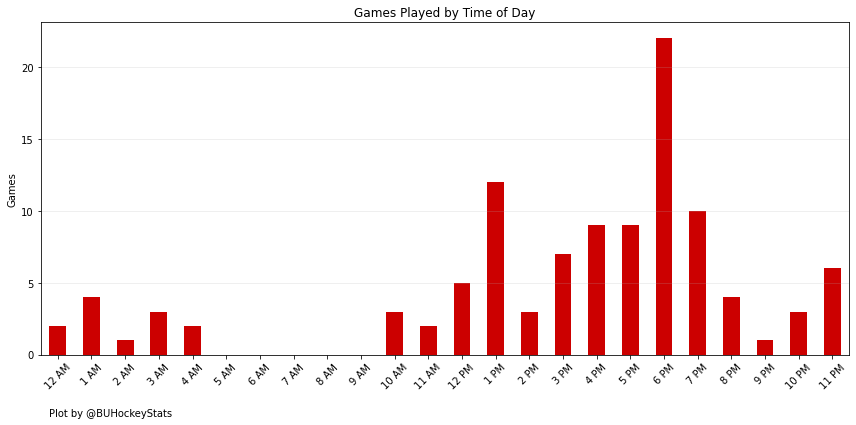

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

dfResults['hour'] = pd.to_datetime(dfResults['timestamp']).dt.hour

hour_counts = (
    dfResults['hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

plt.figure(figsize=(12, 6))

hour_counts.plot(kind='bar',color='#cc0000')

plt.xticks(
    range(24),
    [f'{h % 12 or 12} {"AM" if h < 12 else "PM"}' for h in range(24)],
    rotation=45
)

plt.xlabel('')
plt.ylabel('Games')
plt.title('Games Played by Time of Day')

plt.grid(axis='y', alpha=0.25)
plt.margins(x=0)

plt.text(
    0.01, -0.16,
    'Plot by @BUHockeyStats',
    transform=plt.gca().transAxes,
    ha='left',
    va='top'
)

plt.tight_layout()
plt.show()

In [105]:
dfGrid = dfResults[['gameNumber', 'grid']].copy()

dfGrid['grid'] = dfGrid['grid'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

dfGrid = dfGrid.explode('grid').reset_index(drop=True)

dfGrid = dfGrid.rename(columns={'grid': 'player'})

In [115]:
pd.merge(dfGrid.groupby('player').count().sort_values('gameNumber',ascending=False).reset_index(),dfGrid.sort_values('gameNumber').groupby('player').first().reset_index(),on='player').query('gameNumber_y==3')

,player,gameNumber_x,gameNumber_y
38,Dante Fabbro (2016-19),5,3
66,A.J. Greer (2014-16),2,3
69,Brandon Hickey (2014-18),2,3
75,Grant Rollheiser (2008-12),2,3
77,Jason Lawrence (2005-09),2,3
100,Keith Tkachuk (1990-91),1,3


In [111]:
dfGrid.sort_values('gameNumber').groupby('player').first()

AttributeError: 'DataFrame' object has no attribute 'reset_values'

In [77]:
numGames=len(dfResults)
avgScore=dfResults.score.mean()

In [78]:
def popular_value(col):
    counts = col.dropna().value_counts()

    if counts.empty:
        return None

    value = counts.index[0]
    percentage = counts.iloc[0] / len(col) * 100

    return f'{value} ({percentage:.1f}%)'

In [79]:
import ast
import pandas as pd

dfGrid = pd.DataFrame(dfResults['grid'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x).tolist(), index=dfResults.index)
dfGrid.columns = [f'grid_{i}' for i in range(dfGrid.shape[1])]

# Success rate for each cell
success_rate = dfGrid.notna().mean() * 100

# Most popular answer + percentage for each cell

popular = dfGrid.apply(popular_value)

# Reshape into the 3x3 game grid
success_grid = pd.DataFrame(
    success_rate.values.reshape(game.shape),
    index=game.index,
    columns=game.columns
).round(1)

popular_grid = pd.DataFrame(
    popular.values.reshape(game.shape),
    index=game.index,
    columns=game.columns
)





success_grid

,Captain,Regular Season Champion,25+ Pts (Season)
Goal at Boston (Matthews) Arena,76.0,64.0,84.0
American,80.0,86.0,86.0
All-American,58.0,72.0,86.0


In [80]:
success_grid.round(2)

,Captain,Regular Season Champion,25+ Pts (Season)
Goal at Boston (Matthews) Arena,76.0,64.0,84.0
American,80.0,86.0,86.0
All-American,58.0,72.0,86.0


In [10]:
from collections import Counter

# All guesses for each cell
cell_guesses = {}

for col in dfGrid.columns:
    guesses = dfGrid[col].dropna().tolist()
    cell_guesses[col] = guesses

# Most popular guess across ALL cells
all_guesses = [
    guess
    for col in dfGrid.columns
    for guess in dfGrid[col].dropna()
]

popular_all = Counter(all_guesses)

# Most popular guesses overall
popular_all = pd.DataFrame(
    popular_all.items(),
    columns=['guess', 'count']
).sort_values('count', ascending=False)

popular_all['percentage'] = (
    popular_all['count'] / len(dfGrid) * 100
).round(1)

NameError: name 'dfGrid' is not defined

In [84]:
# All guesses for each cell
# Count of each guess for each cell
cell_counts = dfGrid.apply(lambda col: col.dropna().value_counts().to_dict())

# Reshape into the 3x3 game grid
counts_grid = pd.DataFrame(
    cell_counts.values.reshape(game.shape),
    index=game.index,
    columns=game.columns
)


In [85]:
counts_grid

,Captain,Regular Season Champion,25+ Pts (Season)
Goal at Boston (Matthews) Arena,"{'Shane Lachance (2023-25)': 6, 'Ryan Greene (...","{'Lane Hutson (2022-24)': 5, 'Evan Rodrigues (...","{'Lane Hutson (2022-24)': 7, 'Macklin Celebrin..."
American,"{'Case McCarthy (2019-24)': 6, 'Shane Lachance...","{'Lane Hutson (2022-24)': 3, 'Matt Brown (2021...","{'Quinn Hutson (2022-25)': 8, 'Cole Eiserman (..."
All-American,"{'Chris Drury (1994-98)': 9, 'Matt Gilroy (200...","{'Jack Eichel (2014-15)': 10, 'Lane Hutson (20...","{'Jack Eichel (2014-15)': 14, 'Macklin Celebri..."


In [ ]:
jacksBoxes=[]
gameFN=os.listdir(burb.RECBOOK_DATA_PATH+f'\jacksboxes_grids')[1:-1]
counter=0
for fileName in gameFN:
    game=pd.read_csv(burb.RECBOOK_DATA_PATH+f'jacksboxes_grids\{fileName}',index_col=0)
    jacksBoxes.append({'fn':fileName,'game':game})
    counter+=1